,Method,negative_value,positive_value,contrast_score
0,cell2fate,334.538,40.271,294.267
1,sdevelo,224.016,31.874,192.141
2,veloae,181.706,40.291,141.415
3,dynamo_m1,149.003,24.865,124.137
4,tivelo_simple,78.096,16.378,61.719
5,kvelo,55.933,13.481,42.452
6,tivelo_std,59.097,18.495,40.602
7,sctour_mse,33.460,7.840,25.620
8,celldancer,25.308,8.982,16.326
9,unitvelo_uni,39.917,25.244,14.673


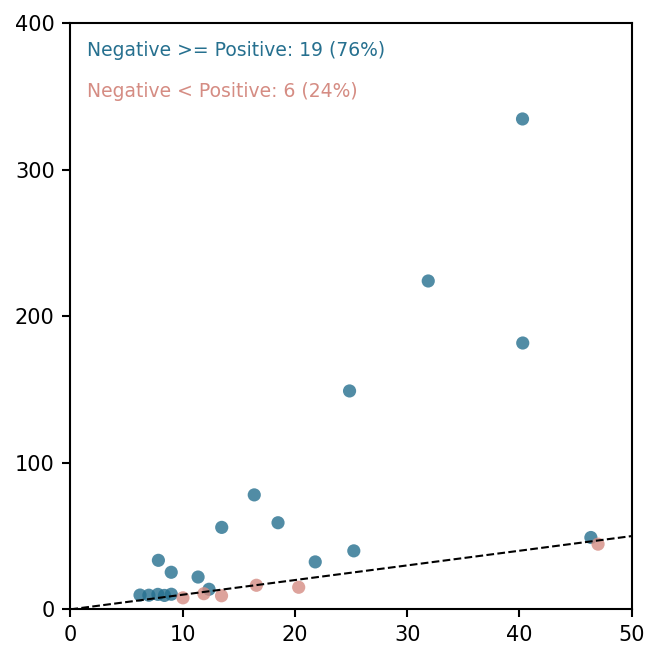

,Method,negative_value,positive_value,contrast_score
0,cell2fate,101.667,40.271,61.396
1,veloae,60.937,40.291,20.646
2,tivelo_std,36.608,18.495,18.113
3,kvelo,30.922,13.481,17.441
4,tivelo_simple,33.453,16.378,17.076
5,sctour_mse,19.672,7.840,11.832
6,deepvelo,29.699,20.336,9.363
7,velovi,19.698,11.888,7.811
8,velovae_std,15.226,8.991,6.234
9,celldancer,12.930,8.982,3.947


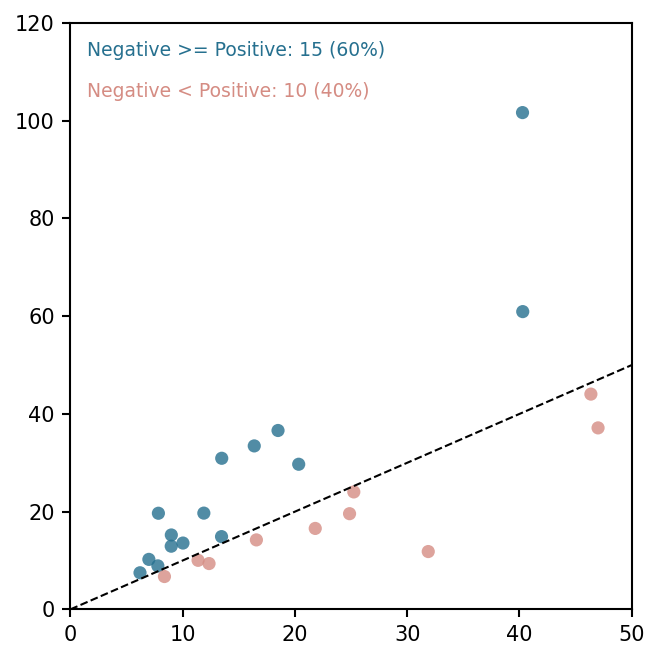

,Method,negative_value,positive_value,contrast_score
0,tivelo_std,46.674,18.495,28.179
1,tivelo_simple,42.708,16.378,26.330
2,sctour_mse,31.524,7.840,23.684
3,cell2fate,56.421,40.271,16.149
4,scvelo_dyn,28.520,16.569,11.950
5,dynamo_m1,33.949,24.865,9.084
6,velovi,20.657,11.888,8.769
7,velocyto,50.481,46.360,4.120
8,veloae,44.155,40.291,3.864
9,celldancer,11.105,8.982,2.123


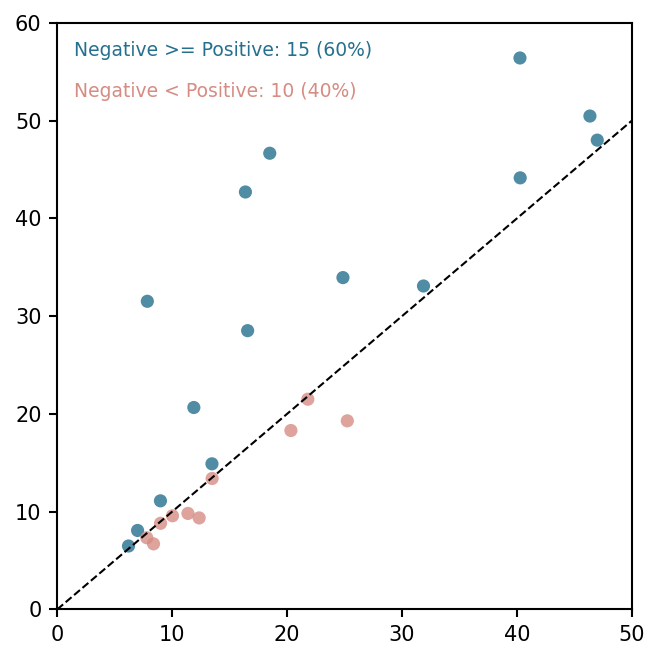

,Method,negative_value,positive_value,contrast_score
0,cell2fate,106.459,40.271,66.188
1,dynamo_m1,81.280,24.865,56.414
2,sdevelo,54.338,31.874,22.463
3,celldancer,30.688,8.982,21.706
4,kvelo,28.693,13.481,15.212
5,veloae,55.389,40.291,15.097
6,tivelo_std,29.098,18.495,10.603
7,sctour_mse,16.916,7.840,9.076
8,tivelo_simple,25.203,16.378,8.825
9,velovi,20.181,11.888,8.293


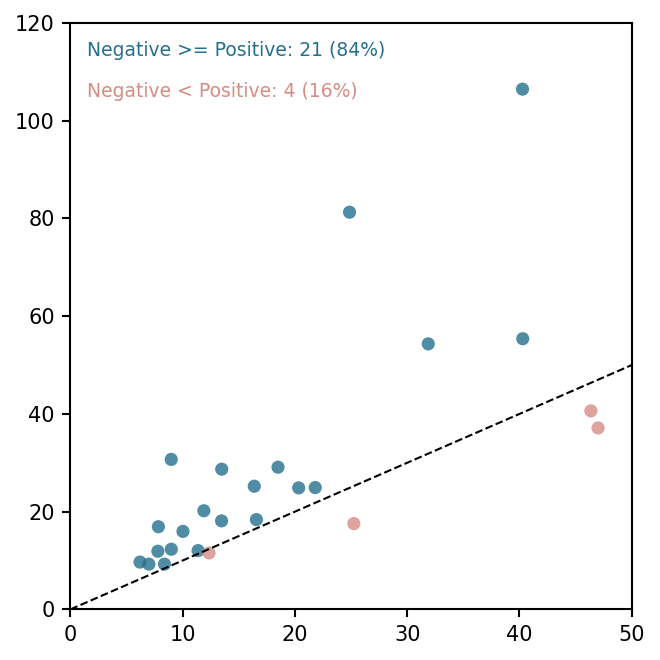

,Method,negative_value,positive_value,contrast_score
0,cell2fate,83.710,40.271,43.439
1,veloae,70.918,40.291,30.627
2,kvelo,36.765,13.481,23.284
3,tivelo_std,33.231,18.495,14.736
4,tivelo_simple,29.799,16.378,13.421
5,deepvelo,31.436,20.336,11.100
6,sctour_mse,16.309,7.840,8.469
7,velovi,19.822,11.888,7.934
8,graphvelo_std,19.349,13.464,5.885
9,velovae_std,13.715,8.991,4.724


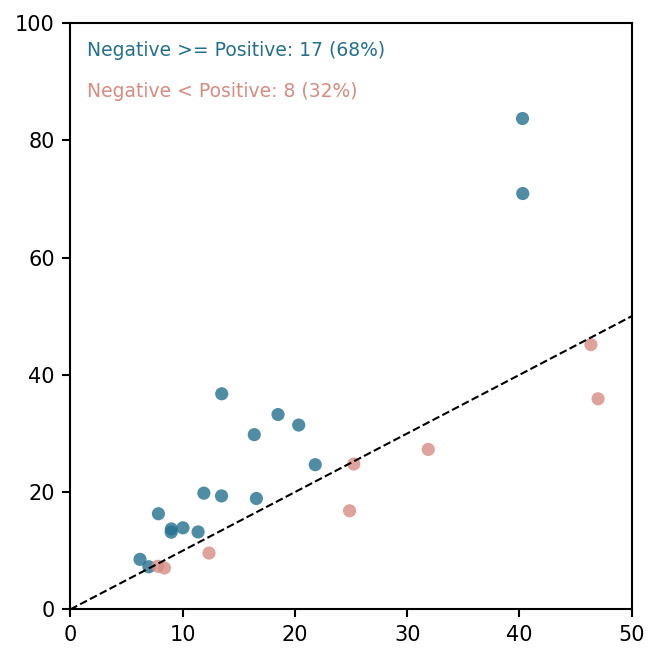

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


def is_fig5_data_dir(path: Path) -> bool:
    required_datasets = ["data04"] + [f"data{i}" for i in range(17, 22)]
    return all((path / dataset / "EES_df.csv").exists() for dataset in required_datasets)


def resolve_fig5_data_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "Figure_reproduction" / "Fig5",
        cwd.parent / "Fig5",
        cwd / "Benchmark-RNA-velocity" / "Figure_reproduction" / "Fig5",
        cwd,
    ]
    for candidate in candidates:
        candidate = candidate.resolve()
        if is_fig5_data_dir(candidate):
            return candidate
    checked_paths = "\n".join(str(path.resolve()) for path in candidates)
    raise FileNotFoundError(f"Could not find Fig5 data directory. Checked:\n{checked_paths}")


DATA_DIR = resolve_fig5_data_dir()
OUTPUT_DIR = Path.cwd().resolve()


def build_ees_mean_df(base_dir: Path) -> pd.DataFrame:
    dataset_names = [f"data{i}" for i in range(17, 22)] + ["data04"]
    records = []

    for dataset_name in dataset_names:
        ees_path = base_dir / dataset_name / "EES_df.csv"
        ees_df = pd.read_csv(ees_path)

        fold_cols = [col for col in ees_df.columns if col != "Method"]
        ees_df[fold_cols] = ees_df[fold_cols].apply(pd.to_numeric, errors="coerce")
        ees_df["value"] = ees_df[fold_cols].mean(axis=1)
        ees_df["Dataset"] = dataset_name

        records.append(ees_df[["Dataset", "Method", "value"]])

    ees_mean_df = pd.concat(records, ignore_index=True)
    ees_mean_df["Dataset"] = pd.Categorical(
        ees_mean_df["Dataset"],
        categories=dataset_names,
        ordered=True,
    )
    return ees_mean_df.sort_values(["Dataset", "Method"]).reset_index(drop=True)


def get_nice_axis_params(values, n_intervals=5):
    values = np.asarray(values, dtype=float)
    vmin = float(np.nanmin(values))
    vmax = float(np.nanmax(values))

    if np.isclose(vmin, vmax):
        pad = max(1.0, abs(vmin) * 0.05)
        vmin -= pad
        vmax += pad

    span = vmax - vmin
    raw_step = span / max(n_intervals, 1)
    magnitude = 10 ** np.floor(np.log10(raw_step))
    normalized = raw_step / magnitude

    if normalized <= 1:
        nice_step = 1
    elif normalized <= 2:
        nice_step = 2
    elif normalized <= 5:
        nice_step = 5
    else:
        nice_step = 10

    tick_step = nice_step * magnitude
    tick_start = tick_step * np.floor(vmin / tick_step)
    tick_end = tick_step * np.ceil(vmax / tick_step)
    ticks = np.arange(tick_start, tick_end + tick_step * 0.1, tick_step)

    return tick_start, tick_end, ticks


ees_mean_df = build_ees_mean_df(DATA_DIR)
positive_dataset = "data04"

sns.set_style("white")

single_negative_datasets_uniform = [f"data{i}" for i in range(17, 22)]
positive_value_uniform = (
    ees_mean_df[ees_mean_df["Dataset"] == positive_dataset][["Method", "value"]]
    .rename(columns={"value": "positive_value"})
)

uniform_above_equal_color = "#26708F"
uniform_below_color = "#D58C83"

for negative_dataset in single_negative_datasets_uniform:
    single_negative_value = (
        ees_mean_df[ees_mean_df["Dataset"] == negative_dataset][["Method", "value"]]
        .rename(columns={"value": "negative_value"})
    )

    single_contrast_df_uniform = single_negative_value.merge(positive_value_uniform, on="Method")
    single_contrast_df_uniform["contrast_score"] = (
        single_contrast_df_uniform["negative_value"] - single_contrast_df_uniform["positive_value"]
    )
    single_contrast_df_uniform = (
        single_contrast_df_uniform.sort_values("contrast_score", ascending=False)
        .reset_index(drop=True)
    )

    display(single_contrast_df_uniform.round(3))

    above_equal_mask = (
        single_contrast_df_uniform["negative_value"] >= single_contrast_df_uniform["positive_value"]
    )
    above_equal_df = single_contrast_df_uniform[above_equal_mask]
    below_df = single_contrast_df_uniform[~above_equal_mask]

    total_count = len(single_contrast_df_uniform)
    above_equal_count = len(above_equal_df)
    below_count = len(below_df)
    above_equal_percent = above_equal_count / total_count * 100 if total_count else 0
    below_percent = below_count / total_count * 100 if total_count else 0

    y_tick_start, y_tick_end, y_ticks = get_nice_axis_params(
        single_contrast_df_uniform["negative_value"]
    )

    plt.figure(figsize=(4.5, 4.5), dpi=150)
    ax = plt.gca()

    ax.scatter(
        above_equal_df["positive_value"],
        above_equal_df["negative_value"],
        s=40,
        color=uniform_above_equal_color,
        alpha=0.8,
        edgecolor="none",
    )
    ax.scatter(
        below_df["positive_value"],
        below_df["negative_value"],
        s=40,
        color=uniform_below_color,
        alpha=0.8,
        edgecolor="none",
    )

    ax.plot([0, 50], [0, 50], linestyle="--", color="black", linewidth=1)

    x_min, x_max = 0, 50
    x_ticks = np.arange(0, 51, 10)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_tick_start, y_tick_end)
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)

    ax.set_xlabel("", fontsize=11)
    ax.set_ylabel("", fontsize=11)

    ax.text(
        0.03,
        0.97,
        f"Negative >= Positive: {above_equal_count} ({above_equal_percent:.0f}%)",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        color=uniform_above_equal_color,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
    )
    ax.text(
        0.03,
        0.90,
        f"Negative < Positive: {below_count} ({below_percent:.0f}%)",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        color=uniform_below_color,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
    )

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color("black")

    ax.tick_params(
        axis="both",
        which="both",
        direction="out",
        length=4,
        width=1,
        colors="black",
        bottom=True,
        top=False,
        left=True,
        right=False,
    )

    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"EES_negative_positive_rationale_x_0_50_uniform_{negative_dataset}.svg",
        bbox_inches="tight",
        dpi=150,
        format="svg"
    )
    plt.show()
